# Lab 1 Part A: OOP Search Algorithms for Drone Pathfinding

**Duration:** 1 week  
**Course topic:** Uninformed Search and Problem Formulation  
**Algorithms:** BFS, DFS, DLS, and IDS  
**Programming style:** Object-Oriented Python

---

## Scenario

You are programming the pathfinding logic of an autonomous drone used for environmental monitoring. The drone surveys difficult terrain to detect environmental degradation, such as illegal small-scale mining activities.

The drone must navigate from a designated **start location** to a **goal location** while avoiding obstacles such as:

- dense forests,
- water bodies,
- dangerous pits,
- restricted zones.

You will model the environment as a **search problem** and implement several search algorithms using an OOP design similar to the AIMA-style pseudocode for `BREADTH-FIRST-SEARCH(problem)` and `EXPAND(problem, node)`.

The goal of this lab is not just to get a path. The goal is to understand how different search strategies behave when the same problem object is passed to them.

# Learning Objectives

By the end of this lab, you should be able to:

1. Formulate a grid navigation task as a formal search problem.
2. Explain the roles of **state**, **action**, **result**, **path cost**, **frontier**, and **reached/explored set**.
3. Implement a reusable `Problem` interface and a `Node` class.
4. Implement and compare:
   - Breadth-First Search (BFS),
   - Depth-First Search (DFS),
   - Depth-Limited Search (DLS),
   - Iterative Deepening Search (IDS).
5. Evaluate algorithms using:
   - solution depth,
   - path cost,
   - number of nodes expanded,
   - maximum frontier/stack size,
   - completeness and optimality.
6. Explain when BFS, DFS, DLS, and IDS are complete or optimal on an unweighted grid.


# Submission Instructions

Complete all code cells marked with `TODO`.

Your final notebook must include:

1. Completed implementations of `GridProblem`, `expand`, BFS, DFS, DLS, and IDS.
2. Output tables comparing the algorithms.
3. Visualisations of at least two solution paths.
4. Answers to all reflection questions.
5. At least two additional maps created by you.
6. An **AI Use Declaration**, whether or not you used an AI tool.

Save your completed notebook as:

```text
FirstName_LastName_Lab_1A.ipynb
```

---

## GitHub Submission

You are required to submit your work through GitHub.

1. Create a GitHub repository for this lab.
2. Add your completed notebook to the repository.
3. Add your **AI Use Declaration** to the repository. This may be included inside the notebook or added as a separate file named `AI_USE_DECLARATION.md`.
4. Commit and push your final solution to GitHub.
5. Make sure the repository is **public** so that it can be accessed and graded.
6. Submit the **GitHub repository link** on Canvas.

Do **not** submit only the `.ipynb` file on Canvas. Canvas should contain the link to your public GitHub repository.

---

## AI Use Declaration Requirement

If you use any AI tool while completing this lab, you must declare it clearly. Examples of AI tools include ChatGPT, Claude, Gemini, Copilot, Perplexity, CodeWhisperer, or any other AI coding or writing assistant.

Your AI use must **not exceed 25% of the entire work**. The main implementation, debugging, explanation, testing, and final decisions must be your own.

Your declaration must include:

1. The **name of the AI tool** used.
2. The **purpose** for which it was used.
3. The **prompts or instructions** given to the tool, where applicable.
4. The **specific parts of the work influenced** by the tool.
5. A short explanation of how you **verified, edited, corrected, tested, or improved** the AI-generated output.

If you did not use any AI tool, write:

```text
I did not use any AI tool to complete this lab.
```

### Attachment of AI Output

Where required by the lecturer, you must attach evidence of AI use. Evidence may include:

- AI-generated drafts,
- prompt history,
- screenshots,
- exported conversations,
- AI-generated code snippets,
- revised versions showing your own input and improvements.

The evidence should make it clear what the AI produced and what you personally changed, tested, corrected, or improved.


---

## Final Submission Checklist

Before submitting, confirm that:

- your notebook opens correctly on GitHub,
- all completed code cells are visible,
- the notebook runs from top to bottom without errors,
- your answers to the reflection questions are included,
- your AI Use Declaration is included,
- any required evidence of AI use is attached,
- your AI use does not exceed 25% of the entire work,
- the repository is public,
- the repository link is accessible without requiring permission.


# 0. How the OOP Design Maps to Search Pseudocode

The search pseudocode uses abstract operations such as `problem.ACTIONS(s)`, `problem.RESULT(s, action)`, and `problem.IS-GOAL(s)`.

In this notebook, these become methods of a `Problem` object.

| Search pseudocode concept | Python/OOP equivalent |
|---|---|
| `problem.INITIAL` | `problem.initial_state()` |
| `problem.IS-GOAL(s)` | `problem.is_goal(state)` |
| `problem.ACTIONS(s)` | `problem.actions(state)` |
| `problem.RESULT(s, action)` | `problem.result(state, action)` |
| `problem.ACTION-COST(s, action, s')` | `problem.action_cost(state, action, next_state)` |
| `NODE(...)` | `Node(...)` dataclass |
| `frontier` | queue, stack, priority queue, or recursion stack |
| `reached` | set or dictionary that prevents unnecessary revisiting |
| `EXPAND(problem, node)` | `SearchAlgorithm.expand(problem, node)` |

This separation is important:

> The `GridProblem` knows the drone environment.  
> The search algorithms know how to search.  
> The `Node` stores the search tree information needed to reconstruct a solution path.

# 1. Setup and Imports

Run the cell below before starting the lab.

In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 2. The Abstract `Problem` Interface

Every search problem must provide the same basic operations.

This lets us write search algorithms that do not depend on the specific problem domain.
The same BFS class should work for a drone map, a road network, a puzzle, or a game state space.

In [ ]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

# 3. The `Node` Class

A state alone is not enough to reconstruct the solution.

A `Node` stores:

- the current state,
- the parent node,
- the action that generated the node,
- the path cost from the start state,
- the depth of the node in the search tree.

This matches the pseudocode:

```text
NODE(STATE=s', PARENT=node, ACTION=action, PATH-COST=cost)
```

In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

# 4. Helper Functions

These helper functions are provided for you.

You will use them to:

- reconstruct paths,
- check for cycles on a single path,
- convert search results into a table.

In [ ]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

# 5. Implementing the Grid Search Problem

In this lab, a state is represented as a tuple:

```python
(row, col)
```

For example:

```python
(0, 0)
```

means row 0, column 0.

The grid uses:

| Cell value | Meaning |
|---|---|
| `0` | Free cell |
| `1` | Obstacle |

The actions are movement directions:

```python
"UP", "DOWN", "LEFT", "RIGHT"
```

Your `GridProblem.actions(state)` method should return only the movements that are legal from the current state.
A move is legal only if the resulting cell is:

1. inside the grid,
2. not an obstacle.

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        if state == self.goal:
            return True
        else:
          return False
        # Return True if state is equal to the goal state.
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.

        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        for action, move in MOVES.items():
          neighbour = (state[0] + move[0], state[1] + move[1])
          if self.in_bounds(neighbour) and self.is_free(neighbour):
            legal_actions.append(action)
          else:
            pass
        return legal_actions
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        dr, dc = MOVES[action]
        return (state[0] + dr, state[1] + dc)
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        if self.is_goal(next_state):
            return 0
        else:
            return 1
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        raise NotImplementedError("Complete GridProblem.action_cost")


## 5.1 Self-Check for `GridProblem`

Run this after completing `GridProblem`.

The test grid is:

```text
S . .
# # .
. . G
```

Expected behaviour:

- Start: `(0, 0)`
- Goal: `(2, 2)`
- From `(0, 0)`, the only legal action is `"RIGHT"`
- Applying `"RIGHT"` from `(0, 0)` gives `(0, 1)`

In [ ]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


# 6. Sample Drone Map

The map below is provided so your lab can run without depending on an internet connection.

You may still create your own maps later.

In [ ]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

# 7. Visualisation Helper

The function below plots:

- obstacles as dark cells,
- the start position,
- the goal position,
- the solution path.

You do not need to modify this function.

In [ ]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

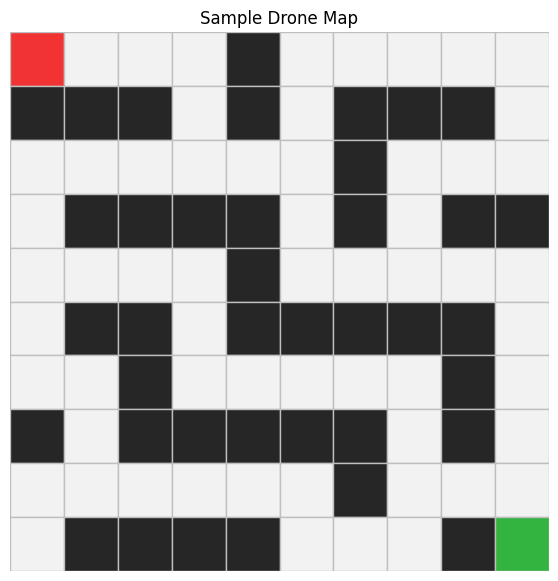

In [ ]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

# 8. The Shared `expand` Method

The pseudocode has a separate `EXPAND(problem, node)` function.

In this OOP design, all search algorithms inherit a common `expand` method.

Complete this method once, then reuse it in BFS, DFS, DLS, and IDS.

The method should:

1. get the current state from the node,
2. ask the problem for legal actions,
3. generate the resulting child state for each action,
4. compute the new path cost,
5. yield a new `Node`.

In [ ]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:

        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:

        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
        #
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION-COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH-COST=cost)

# 9. Breadth-First Search (BFS)

BFS expands nodes in order of increasing depth.

It uses a **FIFO queue**:

- add new nodes at the back,
- remove nodes from the front.

BFS is complete for finite branching factors.  
BFS is optimal when every step has the same cost.

## Your task

Complete the `BreadthFirstSearch.search` method.

## BFS Pseudocode Guide

Study this pseudocode before completing the BFS code cell below. Try to match each pseudocode line to a Python statement in your implementation.

```text
BREADTH-FIRST-SEARCH(problem)
    node ← NODE(problem.INITIAL)

    if problem.IS-GOAL(node.STATE) then
        return node

    frontier ← a FIFO queue with node as an element
    reached ← {problem.INITIAL}

    while frontier is not empty do
        node ← POP(frontier)          // remove from the front of the queue

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if problem.IS-GOAL(s) then
                return child

            if s is not in reached then
                add s to reached
                add child to frontier // add to the back of the queue

    return failure
```

**Python structure to think about:** BFS uses `deque`, `popleft()`, and `append()`.


In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=0,
                reached_count=1
            )

        frontier = deque([node])
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            expanded_children = self.expand(problem, node)

            for child in expanded_children:
              if problem.is_goal(child.state):
                  return SearchResult(
                      algorithm=algorithm,
                      status="success",
                      solution=child,
                      nodes_expanded=nodes_expanded,
                      max_frontier_size=max_frontier_size,
                      reached_count=len(reached)
                  )
              if child.state not in reached:
                reached.add(child.state)
                frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

# 10. Depth-First Search (DFS)

DFS expands the deepest node on the frontier first.

It uses a **LIFO stack**:

- push new nodes onto the stack,
- pop the most recently added node.

DFS is memory-efficient in some cases, but it is not generally optimal.
In infinite state spaces or spaces with cycles, DFS can fail to terminate unless cycle handling or depth limits are used.

## Your task

Complete the `DepthFirstSearch.search` method.

## DFS Pseudocode Guide

Study this pseudocode before completing the DFS code cell below. Notice that DFS uses a stack instead of a queue.

```text
DEPTH-FIRST-SEARCH(problem)
    node ← NODE(problem.INITIAL)

    if problem.IS-GOAL(node.STATE) then
        return node

    frontier ← a LIFO stack with node as an element
    reached ← {problem.INITIAL}

    while frontier is not empty do
        node ← POP(frontier)          // remove from the top/end of the stack

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if problem.IS-GOAL(s) then
                return child

            if s is not in reached then
                add s to reached
                PUSH child onto frontier

    return failure
```

**Python structure to think about:** DFS can use a normal list, with `append()` to push and `pop()` to remove the most recently added node.


In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=0,
                reached_count=1,
            )

        frontier = [node]  # LIFO stack
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = 1  # Initial frontier size is 1

        while frontier:
            node = frontier.pop()  # Pop from the end (LIFO)
            nodes_expanded += 1

            # Reverse children to ensure correct exploration order when popping from stack
            expanded_children = list(self.expand(problem, node))
            expanded_children.reverse()

            for child in expanded_children:
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

# 11. Depth-Limited Search (DLS)

Depth-Limited Search is DFS with a maximum depth limit.

DLS is useful when:

- the state space may be very deep,
- DFS may go down an unhelpful branch,
- we want to restrict the search depth.

DLS can return three statuses:

| Status | Meaning |
|---|---|
| `"success"` | A solution was found |
| `"cutoff"` | The search reached the depth limit before proving failure |
| `"failure"` | No solution exists within the explored part and no cutoff occurred |

## Important note about repeated states

For DLS, use **path-cycle checking** rather than a global reached set.  
This means you should avoid adding a child if its state already appears on the current path from the root to the current node.

Use this helper:

```python
state_is_on_path(node, child.state)
```

## DLS Pseudocode Guide

Study this pseudocode before completing the recursive DLS code cell below. DLS behaves like DFS, but it refuses to search beyond a given depth limit.

```text
DEPTH-LIMITED-SEARCH(problem, limit)
    node ← NODE(problem.INITIAL)
    return RECURSIVE-DLS(node, problem, limit)

RECURSIVE-DLS(node, problem, limit)
    if problem.IS-GOAL(node.STATE) then
        return node, success

    else if node.DEPTH ≥ limit then
        return null, cutoff

    else
        cutoff_occurred ← false

        for each child in EXPAND(problem, node) do
            if child.STATE is already on the current path then
                skip this child

            result, status ← RECURSIVE-DLS(child, problem, limit)

            if status = success then
                return result, success

            else if status = cutoff then
                cutoff_occurred ← true

        if cutoff_occurred then
            return null, cutoff
        else
            return null, failure
```

**Python structure to think about:** DLS is naturally implemented using a helper method such as `_recursive_dls(...)`.


In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:

        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        if problem.is_goal(node.state):
            return (node,"success")
        elif node.depth >= limit:
            return (None, "cutoff")
        else:
          metrics["nodes_expanded"] += 1
          metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)
          cutoff_occurred = False
          for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
              continue
            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size+1)
            result, status = self._recursive_dls(problem, child, limit, metrics, current_stack_size+1)
            if status == "success":
              return (result, "success")
            elif status == "cutoff":
              cutoff_occurred = True
          if cutoff_occurred:
            return (None, "cutoff")
          else:
            return (None, "failure")
        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

# 12. Iterative Deepening Search (IDS)

IDS repeatedly runs DLS with increasing depth limits.

It tries:

```text
limit = 0
limit = 1
limit = 2
limit = 3
...
```

IDS combines some strengths of BFS and DFS:

- It is complete for finite branching factor search spaces.
- It is optimal when step costs are uniform.
- It uses memory similar to DFS.
- It may expand shallow nodes several times.

## Your task

Complete `IterativeDeepeningSearch.search`.

## IDS Pseudocode Guide

Study this pseudocode before completing the IDS code cell below. IDS repeatedly calls DLS with increasing limits.

```text
ITERATIVE-DEEPENING-SEARCH(problem, max_depth)
    for limit from 0 to max_depth do
        result, status ← DEPTH-LIMITED-SEARCH(problem, limit)

        record the limit and status in the iteration log

        if status = success then
            return result

        else if status = failure then
            return failure

    return cutoff
```

**Python structure to think about:** IDS should create a `DepthLimitedSearch` object and call `dls.search(problem, limit=limit)` inside a loop.


In [ ]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        dls = DepthLimitedSearch()

        total_nodes_expanded = 0
        max_overall_frontier_size = 0

        for limit in range(max_depth + 1):
            dls_result = dls.search(problem, limit=limit)

            total_nodes_expanded += dls_result.nodes_expanded
            max_overall_frontier_size = max(max_overall_frontier_size, dls_result.max_frontier_size)

            iteration_log.append({
                "limit": limit,
                "status": dls_result.status
            })

            if dls_result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=dls_result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_overall_frontier_size,
                    iterations=iteration_log
                )

            elif dls_result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_overall_frontier_size,
                    iterations=iteration_log
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_overall_frontier_size,
            iterations=iteration_log
        )

# 13. Run the Algorithms on the Sample Map

Complete all algorithm classes before running this section.

For DLS, choose a depth limit. Try a limit that is too small first, then a limit that is large enough.

In [ ]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,17.0,50,5,52
1,DFS,success,NaN,26.0,25.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,17.0,356,19,0


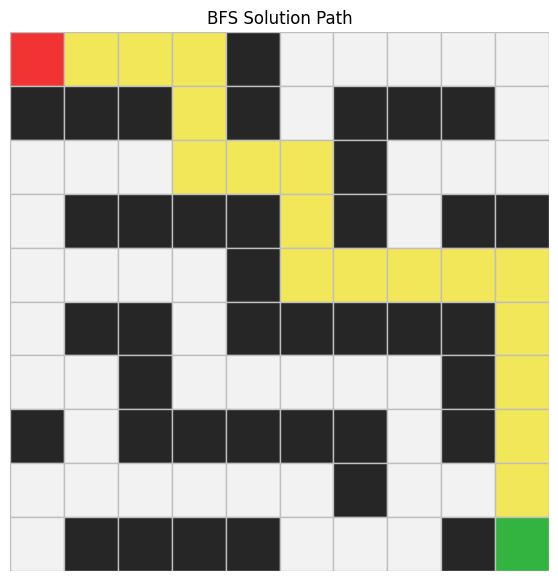

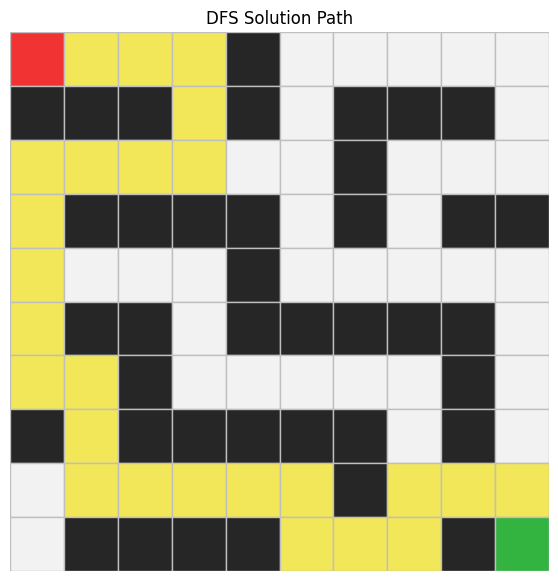

In [ ]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


# 14. Create Your Own Maps

Create at least **two additional maps**.

Your maps should be meaningfully different. For example:

1. A map with a long narrow corridor.
2. A map with many dead ends.
3. A map where DFS is likely to enter dead ends before finding the goal.
4. A larger map, such as 15 × 15 or 20 × 20.

For each map:

- run BFS, DFS, DLS, and IDS,
- record the metrics,
- visualise at least one solution path,
- write a short interpretation.


In [ ]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
[1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
]

custom_start_1 = (0,0)
custom_goal_1 = (2,2)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
    ]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,3,2,3
1,DFS,failure,NaN,None,None,3,2,3
2,DLS,failure,20.0,None,None,3,2,0
3,IDS,failure,NaN,None,None,4,2,0


In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]
]
custom_start_2 = (0,0)
custom_goal_2 = (1,1)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
  bfs.search(custom_problem_2),
  dfs.search(custom_problem_2),
  dls.search(custom_problem_2, limit=20),
  ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,2,1,2,1,2
1,DFS,success,NaN,2,1,2,1,3
2,DLS,success,20.0,2,1,2,3,0
3,IDS,success,NaN,2,1,3,3,0


# 15. Reflection Questions

Answer the questions below in markdown cells.

## 15.1 Problem Formulation

1. What is a state in this lab?
A state is just where the drone is right now on the grid — basically its (row, col) position at that point in the search.

2. What is an action?

An action is one of the moves the drone can make from where it currently is — up, down, left, right (sometimes diagonals too), as long as it's still on the grid and doesn't run into an obstacle.

3. What does the `result` function do?

It takes the current state plus whatever action you picked, and gives you back the new state — so basically "if I'm here and I move this way, where do I end up.

4. Why is it useful to separate the problem definition from the search algorithm?
Mainly so the code stays reusable. If the problem (states, actions, result, goal test) is defined separately, you can plug in BFS, DFS, or whatever algorithm without rewriting the problem itself, and you can swap maps without touching the search logic. Keeps things modular instead of having to redo everything every time something changes.

## 15.2 BFS

1. Why does BFS use a FIFO queue?

Because BFS needs to explore things in the order it found them — first in, first out — so it expands level by level instead of jumping ahead to deeper nodes too early.

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?

Since it checks every node at the current depth before moving to the next depth, the first time it actually reaches the goal, that has to be the shortest path possible (in terms of steps), because there's no way a longer path could've been found first.

3. What role does the `reached` set play in BFS?
It just keeps track of states we've already visited, so we don't waste time expanding the same state twice or get stuck looping on a cycle.

## 15.3 DFS

1. Why does DFS use a stack?
DFS wants to go as deep as possible before backing up, so a stack works well — last node added gets expanded next, which naturally pushes the search deeper instead of wider.

2. Is DFS guaranteed to find the shortest path? Explain.
Nope. DFS just goes with whatever path it finds first — it doesn't compare lengths between branches at all, so it could easily find a long path even when a shorter one exists somewhere else.

3. Under what conditions can DFS use less memory than BFS?

DFS only really has to remember the current path it's on (plus a few unexplored siblings), so its memory use grows pretty much linearly with depth. BFS on the other hand has to hold the entire frontier in memory, which can blow up fast depending on branching factor. So DFS wins on memory especially when the tree is wide.

4. Under what conditions can DFS perform badly?
If the search space has really deep or basically infinite branches that don't lead anywhere near the goal, DFS can get stuck going down a dead-end path for a long time before it backtracks. Also without checking for cycles it can loop forever.

## 15.4 DLS

1. What happens when the depth limit is too small?
The search just won't find the goal at all, even if a solution technically exists — it'll stop early and return cutoff instead.

2. What is the meaning of `"cutoff"`?
It basically means "I ran out of depth before finding anything" — not the same as failure, since failure means there's genuinely no solution at all.

3. How is DLS different from ordinary DFS?
Same idea as DFS, just with a max depth added in. Regular DFS has no limit and will keep going as deep as it can, which is risky on infinite or cyclic graphs.

4. Why do we use path-cycle checking in DLS?
Otherwise the search could waste its limited depth going in circles instead of actually making progress toward the goal.

## 15.5 IDS

1. Why does IDS repeat DLS with increasing limits?
Because we don't actually know how deep the goal is ahead of time, so IDS just keeps trying bigger and bigger limits (0, 1, 2…) until it eventually finds the goal.

2. Why can IDS be complete even though DLS with a small limit is not?
Even if a single DLS run with a small limit fails, IDS doesn't stop there — it keeps increasing the limit until it's deep enough to actually reach the goal. So eventually it will find it.

3. Why does IDS use less memory than BFS?
At any given moment IDS is really just doing a depth-limited DFS, so it only stores one path at a time, not the whole frontier like BFS does.
4. What is the cost of repeatedly searching from the root?
You end up re-expanding the shallow nodes multiple times across iterations, which sounds wasteful, but since most of the nodes are at the deepest level anyway, the extra repeated work doesn't add much overhead overall.

## 15.6 Real-World Drone Context

1. In a real drone application, what might make one route safer or more practical than another?
Stuff like avoiding obstacles and no-fly zones, battery usage, wind, changing altitude, GPS/signal strength, and not flying over crowded areas — not just how many grid squares the path covers.

2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
BFS — it's guaranteed to find the path with the fewest steps when every move costs the same.

3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.

DLS, since it lets you directly cap how deep the search goes, which is useful if you're trying to limit battery use or flight time. IDS could work too if you also want a completeness guarantee.

4. What limitations does this grid model have compared with real drone navigation?
Real drones don't move on a clean 2D grid with equal-cost steps — they deal with wind, altitude changes, moving obstacles, imperfect GPS, and physical limits like turning radius, none of which this simple grid model accounts for.


# 16. Final Checklist

Before submitting, confirm that:

- [ ] `GridProblem` is complete.
- [ ] `SearchAlgorithm.expand` is complete.
- [ ] BFS is complete.
- [ ] DFS is complete.
- [ ] DLS is complete.
- [ ] IDS is complete.
- [ ] You generated comparison tables.
- [ ] You visualised solution paths.
- [ ] You created at least two custom maps.
- [ ] You answered all reflection questions.
- [ ] Your notebook filename follows the required format.
